# 02 - EDA

Exploring `cleaned_house_prices.csv` (output of `01_cleaning.ipynb`) before feature engineering. Goal: understand the price distribution, see how price/sqft varies by location, and define a documented outlier-removal rule.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 20)
sns.set_style('whitegrid')

df = pd.read_csv('../data/cleaned_house_prices.csv')
df.shape

(13303, 8)

13,303 rows, 0 nulls. Matches 13,320 raw rows minus the 17 dropped in step 2 (1 missing `location`, 16 missing `size`).

## Price distribution

In [2]:
df['price'].describe()

count    13303.000000
mean       112.584033
std        148.993820
min          8.000000
25%         50.000000
50%         72.000000
75%        120.000000
max       3600.000000
Name: price, dtype: float64

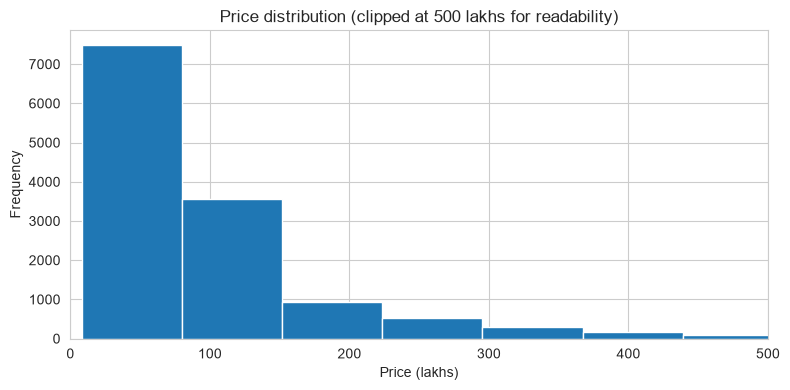

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = [0, 50, 100, 150, 200, 300, 500, 1000, df['price'].max()]
df['price'].plot(kind='hist', bins=50, ax=ax)
ax.set_xlim(0, 500)
ax.set_xlabel('Price (lakhs)')
ax.set_title('Price distribution (clipped at 500 lakhs for readability)')
plt.tight_layout()
plt.show()

Median price is 72 lakhs, mean is 112.6 lakhs. The mean sits well above the median because of a long right tail (max is 3,600 lakhs, a 30 crore listing). 69% of listings are under 100 lakhs.\n\nWhy this matters for step 5: linear regression assumes errors are roughly evenly spread across the price range. With this much right skew, a few expensive listings will dominate the loss and the model will fit them at the expense of the bulk of normal-priced homes. Worth trying a log transform on price (`np.log1p`) when comparing models in step 5, and comparing MAE with and without it.

## Price per sqft by location

In [4]:
df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']
df['price_per_sqft'].describe()

count    1.330300e+04
mean     7.907398e+03
std      1.063169e+05
min      2.257423e+00
25%      4.263483e+03
50%      5.433830e+03
75%      7.313544e+03
max      1.200000e+07
Name: price_per_sqft, dtype: float64

The max here (12 million rupees/sqft) is absurd on its face, that is a preview of the outlier problem below, not a real price level. Ignore the tail for now and look at typical locations first.

In [5]:
top10 = df['location'].value_counts().head(10)
top10

location
Whitefield               539
Sarjapur  Road           397
Electronic City          302
Kanakpura Road           273
Thanisandra              234
Yelahanka                212
Uttarahalli              186
Hebbal                   177
Marathahalli             175
Raja Rajeshwari Nagar    171
Name: count, dtype: int64

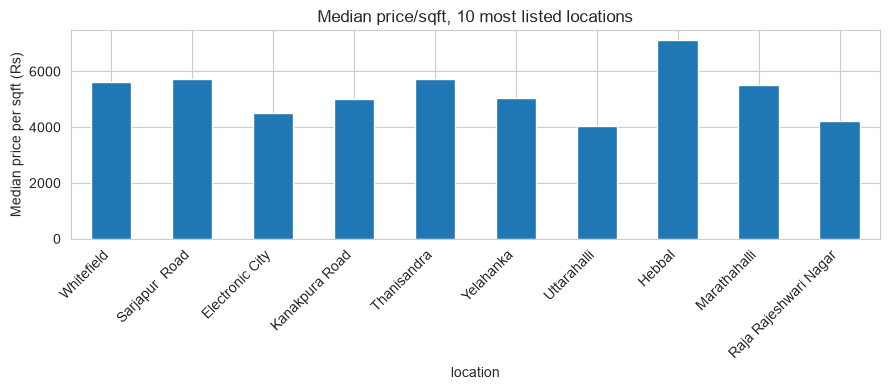

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
med_ppsf = df[df['location'].isin(top10.index)].groupby('location')['price_per_sqft'].median().reindex(top10.index)
med_ppsf.plot(kind='bar', ax=ax)
ax.set_ylabel('Median price per sqft (Rs)')
ax.set_title('Median price/sqft, 10 most listed locations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Hebbal runs about 75% higher per sqft than Uttarahalli (7,112 vs 4,059). Location clearly drives price on its own, independent of size, which confirms it needs to go into the model as a feature in step 4 rather than getting dropped for being messy.

## Location cardinality

In [7]:
n_locations = df['location'].nunique()
single_listing = (df['location'].value_counts() <= 1).sum()
under_10 = (df['location'].value_counts() <= 10).sum()
print(f'{n_locations} unique locations')
print(f'{single_listing} locations ({single_listing/n_locations:.0%}) have exactly 1 listing')
print(f'{under_10} locations ({under_10/n_locations:.0%}) have 10 or fewer listings')

1304 unique locations
479 locations (37%) have exactly 1 listing
1063 locations (82%) have 10 or fewer listings


This is the step-4 problem stated in numbers: 1,304 unique locations, 81% of them with 10 or fewer listings. One-hot encoding all of them gives the model hundreds of near-useless single-row features. A bucket cutoff around 10-20 listings (everything below folds into `other`) keeps the signal from the well-represented locations like Whitefield (539 listings) without the long useless tail.

## Outlier check 1: the land parcel

In [8]:
df.loc[df['total_sqft'].idxmax()]

area_type         Plot  Area
availability          19-Mar
location          Narasapura
bath                     2.0
balcony                  2.0
price                   29.5
total_sqft         1306800.0
bhk                      2.0
price_per_sqft      2.257423
Name: 1084, dtype: object

`total_sqft` = 1,306,800 is exactly 30 acres converted with the lookup from step 2 (30 * 43,560 = 1,306,800), so the unit conversion is correct. The problem is that this is a 30-acre land parcel sitting in a dataset of apartment listings. Its `price_per_sqft` works out to Rs 2.26, versus a citywide median around Rs 5,400. Left in, this single row would blow out any per-sqft-based outlier bound computed downstream. Needs to be dropped before anything else.

## Outlier check 2: implausible bath vs bhk

In [9]:
implausible_bath = df[df['bath'] > df['bhk'] + 2]
print(len(implausible_bath), 'rows')
implausible_bath.sort_values('bath', ascending=False)[['location', 'total_sqft', 'bhk', 'bath', 'price']].head(8)

16 rows


,location,total_sqft,bhk,bath,price
1076,BTM 1st Stage,3300.0,9.0,14.0,500.0
10680,Electronic City,1200.0,9.0,13.0,150.0
13050,Defence Colony,7150.0,10.0,13.0,3600.0
1950,KR Puram,1200.0,8.0,12.0,110.0
8095,Wilson Garden,1850.0,8.0,12.0,300.0
6927,5th Block Hbr Layout,2600.0,9.0,12.0,675.0
1976,Hongasandra,990.0,8.0,12.0,120.0
2616,Sathya Sai Layout,11338.0,6.0,9.0,1000.0


16 rows where bath count exceeds bedroom count by more than 2. Worst case is 43 bhk / 40 bath on 2,400 sqft, a studio-sized lot cannot have 43 bedrooms. These read as data entry errors (digits transposed or duplicated at the source), not real floor plans.

## Outlier check 3: sqft per bedroom too low

In [10]:
df['sqft_per_bhk'] = df['total_sqft'] / df['bhk']
too_small = df[df['sqft_per_bhk'] < 300]
print(len(too_small), f'rows ({len(too_small)/len(df):.1%})')
too_small[['location', 'total_sqft', 'bhk', 'bath', 'price', 'sqft_per_bhk']].sort_values('sqft_per_bhk').head(8)

748 rows (5.6%)


,location,total_sqft,bhk,bath,price,sqft_per_bhk
4080,Sarjapur Road,1.0000,4.0,4.0,120.0,0.250000
4966,Srirampuram,5.0000,7.0,7.0,115.0,0.714286
349,Suragajakkanahalli,11.0000,3.0,3.0,74.0,3.666667
1120,Grihalakshmi Layout,24.0000,5.0,2.0,150.0,4.800000
1018,Weavers Colony,15.0000,1.0,1.0,30.0,15.000000
11542,Whitefield,60.0000,4.0,4.0,218.0,15.000000
5963,Mysore Road,45.0000,1.0,1.0,23.0,45.000000
12235,Gowdanapalya,258.3336,5.0,5.0,75.0,51.666720


748 rows (5.6%) have less than 300 sqft per bedroom, including one row with `total_sqft` = 1 and `bhk` = 4. 300 sqft/bedroom is a realistic floor for a legitimate small bedroom, so rows below it are far more likely to be a mistyped bhk count or sqft value than an actual micro-apartment.

## Outlier check 4: malformed location strings

In [11]:
malformed = df[df['location'].str.match(r'^\d+[A-Za-z]')]
print(len(malformed), 'rows')
malformed['location'].unique()

548 rows


<StringArray>
[                             '7th Phase JP Nagar',
                              '8th Phase JP Nagar',
                           '8th block Koramangala',
                             '1st Block Jayanagar',
                              '9th Phase JP Nagar',
                              '6th Phase JP Nagar',
                              '5th Phase JP Nagar',
                            '2nd Stage Nagarbhavi',
                           '3rd Block Hrbr Layout',
                             '7th Block Jayanagar',
                              '2nd Phase JP Nagar',
  '6th block banashankari 3rd stage, 100 feet ORR',
                              '1st Phase JP Nagar',
                           '2nd Block Hrbr Layout',
                            '5th Block Hbr Layout',
                       '2nd Phase Judicial Layout',
                           '1st Block HRBR Layout',
                             '9th Block Jayanagar',
                             '3rd Block Jayanagar'

Most locations starting with a digit are legitimate (`7th Phase JP Nagar`, `1st Block Jayanagar`, phase and block numbers are real naming conventions here). But 5 distinct values are missing a space and are genuinely malformed: `1Hanuman Nagar`, `2Electronic City Phase II`, `1Channasandra`, `1Hoysalanagar`, `1Kasavanhalli`. Left as-is, each becomes its own useless singleton location in step 4's bucketing. Worth a targeted fix rather than a blanket digit-strip, since stripping digits from `7th Phase JP Nagar` would break a real location name.

## Applying the outlier rule

Rule, in order:\n\n1. Drop the land parcel row (`total_sqft` > 100,000, effectively a non-residential listing).\n2. Drop rows where `bath > bhk + 2`.\n3. Drop rows where `total_sqft / bhk < 300`.\n4. Fix the 5 malformed location strings (add the missing space) rather than dropping those rows, since the listings themselves look legitimate.\n\nPrice-per-sqft outliers are deliberately left for step 4, after location bucketing, since a sensible price/sqft bound has to be computed per location (Rs 4,000/sqft is normal in Uttarahalli, but would be a steep discount in Hebbal). A single global cutoff here would wrongly flag entire cheap or expensive neighborhoods.

In [12]:
import re

def fix_location(loc):
    return re.sub(r'^(\d+)([A-Za-z])', r'\1 \2', loc) if loc in malformed['location'].unique() else loc

before = len(df)

df = df[df['total_sqft'] <= 100000]
df = df[df['bath'] <= df['bhk'] + 2]
df = df[df['sqft_per_bhk'] >= 300]
df['location'] = df['location'].apply(fix_location)

after = len(df)
print(f'{before} rows before, {after} after, {before - after} dropped ({(before-after)/before:.1%})')

13303 rows before, 12540 after, 763 dropped (5.7%)


In [13]:
df = df.drop(columns=['sqft_per_bhk'])
df.to_csv('../data/house_prices_no_outliers.csv', index=False)
df.shape

(12540, 9)

Output: `data/house_prices_no_outliers.csv`, ready for step 4 (location bucketing and feature engineering).